In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('injection_molding.csv')
df.drop(columns=['timestamp'], inplace=True)
df.head(1)

,mold_name,material_name,machine_tonnage,cycle_number,hopper_temp,nozzle_temp,H1,H2,H3,mold_core_temp,...,total_cycle_time,Hopper_State,Barrel_Heater_State,Screw_State,Injection_Unit_State,Hydraulic_System_State,Clamp_Unit_State,Mold_State,Cooling_System_State,Ejector_System_State
0,Smart Router Enclosure,"ABS (Flame Retardant, Medium Flow)",180,1,45,230,225,211,201,67,...,24.61,0,0,0,0,0,0,0,0,0


In [3]:
target = ['Hopper_State','Barrel_Heater_State', 'Screw_State', 'Injection_Unit_State','Hydraulic_System_State', 
               'Clamp_Unit_State', 'Mold_State','Cooling_System_State', 'Ejector_System_State']  
sensor = [i for i in df.columns if i not in target]
sensor.remove('mold_name')
sensor.remove('material_name')
len(sensor)

34

In [4]:
def find_correlation(corr, threshold=0.95):
    """Iteratively drop the more globally-redundant column of the most-correlated
    remaining pair, until no pair exceeds threshold. Avoids over-pruning chains."""
    corr = corr.abs().copy()
    vals = corr.values.copy()
    np.fill_diagonal(vals, 0)  # ignore self-correlation
    corr = pd.DataFrame(vals, index=corr.index, columns=corr.columns)
    to_drop = []
    while True:
        max_corr = corr.values.max()
        if max_corr <= threshold or corr.shape[0] <= 1:
            break
        i, j = np.unravel_index(np.argmax(corr.values), corr.shape)
        col_i, col_j = corr.index[i], corr.columns[j]
        # drop whichever has the higher average correlation with everything else remaining
        drop_col = col_i if corr[col_i].mean() > corr[col_j].mean() else col_j
        to_drop.append(drop_col)
        corr = corr.drop(index=drop_col, columns=drop_col)
    return to_drop

# correlation-based pruning of redundant raw sensor columns
corr = df[sensor].corr()
to_drop = find_correlation(corr, threshold=0.95)
kept_numeric_cols = [c for c in sensor if c not in to_drop]
df.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} redundant (|r|>0.95) columns, kept {len(kept_numeric_cols)}:")
print(kept_numeric_cols)

Dropped 18 redundant (|r|>0.95) columns, kept 16:
['cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2', 'back_pressure', 'decompression_speed', 'decompression_distance', 'cushion_size', 'clamp_force', 'mold_protection_pressure', 'ejection_stroke', 'part_weight']


In [5]:
df.columns

Index(['mold_name', 'material_name', 'cycle_number', 'hopper_temp', 'H1',
       'mold_cavity_temp', 'inj_speed1', 'actual_inj_pressure',
       'vp_transition', 'holding_pressure_stage2', 'back_pressure',
       'decompression_speed', 'decompression_distance', 'cushion_size',
       'clamp_force', 'mold_protection_pressure', 'ejection_stroke',
       'part_weight', 'Hopper_State', 'Barrel_Heater_State', 'Screw_State',
       'Injection_Unit_State', 'Hydraulic_System_State', 'Clamp_Unit_State',
       'Mold_State', 'Cooling_System_State', 'Ejector_System_State'],
      dtype='str')

# Train Test  Split

In [6]:
import pandas as pd 
train_list = []
val_list = []
test_list = []
# Sort first
df = df.sort_values(['mold_name', 'cycle_number']).reset_index(drop=True)
for mold_id, group in df.groupby('mold_name'):
    n = len(group)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    train_list.append(group.iloc[:train_end])
    val_list.append(group.iloc[train_end:val_end])
    test_list.append(group.iloc[val_end:])
train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True)
test_df = pd.concat(test_list).reset_index(drop=True)
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 27)
Validation: (6000, 27)
Test: (6000, 27)


In [7]:
window = 5
temp_pressure  = ['hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1','holding_pressure_stage2', 'back_pressure', 'decompression_speed','mold_protection_pressure', 'ejection_stroke', 'part_weight']

def add_engineered_features(data, window=window, temp_pressure=temp_pressure, kept_numeric_cols=kept_numeric_cols):
    data = data.sort_values(['mold_name', 'cycle_number']).reset_index(drop=True)
    grp = data.groupby('mold_name')

    # rolling mean & std
    roll_mean = grp[temp_pressure].rolling(window, min_periods=1).mean().droplevel(0)
    roll_mean.columns = [f'{c}_roll_mean' for c in temp_pressure]

    roll_std = grp[temp_pressure].rolling(window, min_periods=1).std().droplevel(0)
    roll_std.columns = [f'{c}_roll_std' for c in temp_pressure]

    # delta
    delta = grp[kept_numeric_cols].diff()
    delta.columns = [f'{c}_delta' for c in kept_numeric_cols]

    eng = pd.concat([roll_mean, roll_std, delta], axis=1).sort_index().fillna(0.0)
    return pd.concat([data, eng], axis=1)

train_df = add_engineered_features(train_df)
val_df = add_engineered_features(val_df)
test_df = add_engineered_features(test_df)

print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (28000, 63)
Validation: (6000, 63)
Test: (6000, 63)


In [8]:
#ohe on mold id
def add_mold_dummies(data):
    enc = pd.get_dummies(data['mold_name'], prefix='mold_name', dtype=int)
    return pd.concat([enc,data], axis=1)

train_df = add_mold_dummies(train_df)
val_df = add_mold_dummies(val_df)
test_df = add_mold_dummies(test_df)

In [9]:
train_df.columns

Index(['mold_name_Blood Filtration Housing', 'mold_name_Engine Mount Bracket',
       'mold_name_Rectangular Food Container',
       'mold_name_Smart Router Enclosure', 'mold_name', 'material_name',
       'cycle_number', 'hopper_temp', 'H1', 'mold_cavity_temp', 'inj_speed1',
       'actual_inj_pressure', 'vp_transition', 'holding_pressure_stage2',
       'back_pressure', 'decompression_speed', 'decompression_distance',
       'cushion_size', 'clamp_force', 'mold_protection_pressure',
       'ejection_stroke', 'part_weight', 'Hopper_State', 'Barrel_Heater_State',
       'Screw_State', 'Injection_Unit_State', 'Hydraulic_System_State',
       'Clamp_Unit_State', 'Mold_State', 'Cooling_System_State',
       'Ejector_System_State', 'hopper_temp_roll_mean', 'H1_roll_mean',
       'mold_cavity_temp_roll_mean', 'inj_speed1_roll_mean',
       'holding_pressure_stage2_roll_mean', 'back_pressure_roll_mean',
       'decompression_speed_roll_mean', 'mold_protection_pressure_roll_mean',
       'eje

In [10]:
# scaling numeric features
scaler = StandardScaler()
id_cat_cols = ['mold_name', 'material_name']
mold_dummy_cols = [c for c in train_df.columns if c.startswith('mold_name_')]

exclude_cols = id_cat_cols + target + mold_dummy_cols

numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

In [11]:
train_df.drop(columns=['mold_name','material_name'],inplace=True)
val_df.drop(columns=['mold_name','material_name'],inplace=True)
test_df.drop(columns=['mold_name','material_name'],inplace=True)

In [12]:
def reorder_target_last(data, target=target):
    cols = [c for c in data.columns if c not in target] + target
    return data[cols]

train_df = reorder_target_last(train_df)
val_df = reorder_target_last(val_df)
test_df = reorder_target_last(test_df)

X_train, y_train = train_df.drop(columns=target), train_df[target]
X_val, y_val = val_df.drop(columns=target), val_df[target]
X_test, y_test = test_df.drop(columns=target), test_df[target]

# Anomaly/ Novelty detection

Same 5 algorithms as the "Per-Subsystem Anomaly Detection (9 targets)" section of `maintenance_model_building.ipynb` — **Isolation Forest, ECOD, COPOD, LOF, Autoencoder** — fit independently per subsystem target. The difference: instead of feeding every column to every target's detectors, each target only sees the sensor column(s) that `synthetic_data_eda.ipynb` (section 7, *"Do the sensor features actually relate to their matching component state?"*) showed actually move with that subsystem's state (the boxplot check + its follow-up feature-importance check).

For each target column `col`:
- Train only on `train_df` rows where `col == 0` (healthy for *that* subsystem specifically).
- Feature set: `target_feature_map[col]` — the EDA-identified raw column for that target, plus its engineered `_roll_mean` / `_roll_std` / `_delta` variants where available.
- Score every row of `train_df`/`val_df`/`test_df`, stored as `f'{col}_{algo}_score'`.
- Evaluate on val/test with PR-AUC, ROC-AUC, Recall, ground truth `col != 0`.

Note: 3 of the EDA boxplot's columns (`mold_close_speed` for Clamp, `cooling_time` for Cooling, `ejection_speed` for Ejector) got dropped earlier by the `|r|>0.95` correlation pruning, so they no longer exist in `train_df`. For those, the closest still-available column — by the EDA's RandomForest feature-importance ranking against that target — is used instead: `mold_protection_pressure` + `clamp_force` for `Clamp_Unit_State`, `mold_cavity_temp` for `Cooling_System_State`, `ejection_stroke` for `Ejector_System_State`.

In [13]:
# Which raw sensor column(s) drive each target, per the EDA check in synthetic_data_eda.ipynb
# section 7 ("Do the sensor features actually relate to their matching component state?").
# For the 3 targets whose EDA column was dropped earlier by the |r|>0.95 correlation pruning
# (mold_close_speed, cooling_time, ejection_speed), the closest still-available column -- by
# RandomForest feature importance against that target, computed in the EDA notebook -- is used instead.
target_base_cols = {
    'Hopper_State': ['hopper_temp'],
    'Barrel_Heater_State': ['H1'],
    'Screw_State': ['back_pressure'],
    'Injection_Unit_State': ['actual_inj_pressure'],
    'Hydraulic_System_State': ['clamp_force'],
    'Clamp_Unit_State': ['mold_protection_pressure', 'clamp_force'],  # mold_close_speed dropped -> substitutes
    'Mold_State': ['mold_cavity_temp'],
    'Cooling_System_State': ['mold_cavity_temp'],                     # cooling_time dropped -> substitute
    'Ejector_System_State': ['ejection_stroke'],                      # ejection_speed dropped -> substitute
}

def expand_features(base_cols, temp_pressure=temp_pressure, kept_numeric_cols=kept_numeric_cols):
    """Raw column + its engineered roll_mean/roll_std (if in temp_pressure) and delta (if in kept_numeric_cols)."""
    feats = []
    for c in base_cols:
        feats.append(c)
        if c in temp_pressure:
            feats += [f'{c}_roll_mean', f'{c}_roll_std']
        if c in kept_numeric_cols:
            feats.append(f'{c}_delta')
    seen = set()
    return [f for f in feats if not (f in seen or seen.add(f))]

target_feature_map = {col: expand_features(cols) for col, cols in target_base_cols.items()}
for col, feats in target_feature_map.items():
    print(f'{col:24s} -> {feats}')

Hopper_State             -> ['hopper_temp', 'hopper_temp_roll_mean', 'hopper_temp_roll_std', 'hopper_temp_delta']
Barrel_Heater_State      -> ['H1', 'H1_roll_mean', 'H1_roll_std', 'H1_delta']
Screw_State              -> ['back_pressure', 'back_pressure_roll_mean', 'back_pressure_roll_std', 'back_pressure_delta']
Injection_Unit_State     -> ['actual_inj_pressure', 'actual_inj_pressure_delta']
Hydraulic_System_State   -> ['clamp_force', 'clamp_force_delta']
Clamp_Unit_State         -> ['mold_protection_pressure', 'mold_protection_pressure_roll_mean', 'mold_protection_pressure_roll_std', 'mold_protection_pressure_delta', 'clamp_force', 'clamp_force_delta']
Mold_State               -> ['mold_cavity_temp', 'mold_cavity_temp_roll_mean', 'mold_cavity_temp_roll_std', 'mold_cavity_temp_delta']
Cooling_System_State     -> ['mold_cavity_temp', 'mold_cavity_temp_roll_mean', 'mold_cavity_temp_roll_std', 'mold_cavity_temp_delta']
Ejector_System_State     -> ['ejection_stroke', 'ejection_stroke_roll_

In [14]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, recall_score

subsystem_results = []  # (Algorithm, Target, Split, PR_AUC, ROC_AUC, Recall) rows, val/test only

def evaluate_subsystem(algorithm, col, split_name, y_true, y_score, y_pred):
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = auc(recall, precision)
    subsystem_results.append({
        'Algorithm': algorithm, 'Target': col, 'Split': split_name,
        'PR_AUC': pr_auc,
        'ROC_AUC': roc_auc_score(y_true, y_score),
        'Recall': recall_score(y_true, y_pred),
    })

### 1. Isolation Forest

In [15]:
from sklearn.ensemble import IsolationForest

iso_forest_subsystem = {}  # target column -> fitted IsolationForest

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = IsolationForest(n_estimators=200, contamination='auto', random_state=42, n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, feats])
    iso_forest_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_iso_score'] = score

        if split_name != 'train':  # evaluate only on held-out splits
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Isolation Forest', col, split_name, y_true, score, pred)

print("Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.")

Isolation Forest: added '<target>_iso_score' to train_df/val_df/test_df for all 9 subsystems.


### 2. ECOD

In [16]:
from pyod.models.ecod import ECOD

ecod_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = ECOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, feats])
    ecod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_ecod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('ECOD', col, split_name, y_true, score, pred)

print("ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.")

ECOD: added '<target>_ecod_score' to train_df/val_df/test_df for all 9 subsystems.


### 3. COPOD

In [17]:
from pyod.models.copod import COPOD

copod_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = COPOD(contamination=0.1)
    model.fit(train_df.loc[healthy_rows, feats])
    copod_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_copod_score'] = score

        if split_name != 'train':
            pred = model.predict(X_split)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('COPOD', col, split_name, y_true, score, pred)

print("COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.")

COPOD: added '<target>_copod_score' to train_df/val_df/test_df for all 9 subsystems.


### 4. Local Outlier Factor (LOF)

In [18]:
from sklearn.neighbors import LocalOutlierFactor

lof_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    model = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination='auto', n_jobs=-1)
    model.fit(train_df.loc[healthy_rows, feats])
    lof_subsystem[col] = model

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats]
        score = -model.decision_function(X_split)  # higher = more anomalous
        split_df[f'{col}_lof_score'] = score

        if split_name != 'train':
            pred = (model.predict(X_split) == -1).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('LOF', col, split_name, y_true, score, pred)

print("LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.")

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


...

C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF: added '<target>_lof_score' to train_df/val_df/test_df for all 9 subsystems.


C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(
C:\Users\janukrish\Desktop\capstone_proj\AI-Based-PM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


### 5. Autoencoder

In [19]:
import keras
from keras import layers

autoencoder_subsystem = {}

for col in target:
    feats = target_feature_map[col]
    healthy_rows = train_df[col] == 0
    X_train_healthy_col = train_df.loc[healthy_rows, feats]

    n_features = X_train_healthy_col.shape[1]
    encoding_dim = max(2, n_features // 4)

    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(encoding_dim, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_features, activation='linear'),
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_healthy_col.values, X_train_healthy_col.values,
        epochs=50, batch_size=64, validation_split=0.1,
        shuffle=True, verbose=0,
    )
    autoencoder_subsystem[col] = model

    # threshold from this subsystem's own healthy-training reconstruction error (99th percentile)
    recon_train_healthy = model.predict(X_train_healthy_col.values, verbose=0)
    train_healthy_errors = np.mean(np.square(X_train_healthy_col.values - recon_train_healthy), axis=1)
    ae_threshold = np.percentile(train_healthy_errors, 99)

    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        X_split = split_df[feats].values
        recon = model.predict(X_split, verbose=0)
        score = np.mean(np.square(X_split - recon), axis=1)  # higher = more anomalous
        split_df[f'{col}_ae_score'] = score

        if split_name != 'train':
            pred = (score > ae_threshold).astype(int)
            y_true = (split_df[col] != 0).astype(int)
            evaluate_subsystem('Autoencoder', col, split_name, y_true, score, pred)

print("Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.")

C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


...

C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


Autoencoder: added '<target>_ae_score' to train_df/val_df/test_df for all 9 subsystems.


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\2951297141.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_ae_score'] = score


### Results

In [20]:
# Comparison table: PR-AUC / ROC-AUC / Recall per (Algorithm, Target, Split)
subsystem_results_df = pd.DataFrame(subsystem_results)
subsystem_results_summary = (subsystem_results_df
                              .set_index(['Algorithm', 'Target', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
                              .round(4))
subsystem_results_summary

PR_AUC  ROC_AUC  Recall
Algorithm        Target               Split                         
Isolation Forest Hopper_State         val    0.4018   0.6627  0.4976
                                      test   0.4632   0.6997  0.5694
                 Barrel_Heater_State  val    0.2760   0.8348  0.8817
                                      test   0.5537   0.8502  0.9143
                 Screw_State          val    0.3509   0.7075  0.6243
...                                             ...      ...     ...
Autoencoder      Mold_State           test   0.3238   0.6146  0.0126
                 Cooling_System_State val    0.1975   0.4490  0.0174
                                      test   0.1560   0.4872  0.0020
                 Ejector_System_State val    0.4492   0.6295  0.0031
                                      test   0.3667   0.6095  0.0060

[90 rows x 3 columns]

In [21]:
subsystem_results_summary[0:18]

PR_AUC  ROC_AUC  Recall
Algorithm        Target                 Split                         
Isolation Forest Hopper_State           val    0.4018   0.6627  0.4976
                                        test   0.4632   0.6997  0.5694
                 Barrel_Heater_State    val    0.2760   0.8348  0.8817
                                        test   0.5537   0.8502  0.9143
                 Screw_State            val    0.3509   0.7075  0.6243
                                        test   0.2994   0.7012  0.5872
                 Injection_Unit_State   val    0.2671   0.6862  0.4724
                                        test   0.4710   0.7290  0.6585
                 Hydraulic_System_State val    0.1553   0.6715  0.4393
                                        test   0.3981   0.6736  0.4809
                 Clamp_Unit_State       val    0.1952   0.6468  0.4386
                                        test   0.2600   0.6911  0.4892
                 Mold_State             val    0.3517   0.7439  0.5473
                                        test   0.3668   0.6551  0.4382
                 Cooling_System_State   val    0.2928   0.6236  0.4880
                                        test   0.3887   0.6793  0.5808
                 Ejector_System_State   val    0.6439   0.8026  0.7506
                                        test   0.4021   0.6512  0.5237

In [22]:
subsystem_results_summary[18:36]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
ECOD      Hopper_State           val    0.3271   0.4776  0.1765
                                 test   0.3925   0.4944  0.2446
          Barrel_Heater_State    val    0.0695   0.3029  0.0063
                                 test   0.2858   0.4015  0.1597
          Screw_State            val    0.2736   0.4265  0.2265
                                 test   0.3475   0.4603  0.3933
          Injection_Unit_State   val    0.2204   0.5203  0.1727
                                 test   0.4423   0.6353  0.3815
          Hydraulic_System_State val    0.1481   0.5679  0.2150
                                 test   0.3710   0.5825  0.2296
          Clamp_Unit_State       val    0.1352   0.5281  0.0351
                                 test   0.1758   0.5640  0.0676
          Mold_State             val    0.2058   0.4562  0.1579
                                 test   0.2712   0.4418  0.1597
          Cooling_System_State   val    0.1449   0.3490  0.0157
                                 test   0.2342   0.5587  0.1414
          Ejector_System_State   val    0.5447   0.6502  0.3129
                                 test   0.3000   0.4144  0.1937

In [23]:
subsystem_results_summary[36:54]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
COPOD     Hopper_State           val    0.3763   0.5162  0.2005
                                 test   0.4746   0.5427  0.2896
          Barrel_Heater_State    val    0.0833   0.4208  0.0095
                                 test   0.3321   0.4930  0.1643
          Screw_State            val    0.2741   0.3784  0.2282
                                 test   0.3751   0.5197  0.4031
          Injection_Unit_State   val    0.2457   0.5678  0.2102
                                 test   0.4810   0.6607  0.4315
          Hydraulic_System_State val    0.1843   0.5126  0.2477
                                 test   0.4492   0.5743  0.3065
          Clamp_Unit_State       val    0.1800   0.6105  0.1216
                                 test   0.2130   0.5955  0.1618
          Mold_State             val    0.1694   0.4809  0.0845
                                 test   0.2119   0.4397  0.0983
          Cooling_System_State   val    0.1494   0.3710  0.0165
                                 test   0.1986   0.5646  0.1182
          Ejector_System_State   val    0.4312   0.6296  0.1500
                                 test   0.2337   0.4293  0.1156

In [24]:
subsystem_results_summary[54:72]

PR_AUC  ROC_AUC  Recall
Algorithm Target                 Split                         
LOF       Hopper_State           val    0.5400   0.7481  0.4556
                                 test   0.6744   0.8242  0.5627
          Barrel_Heater_State    val    0.5031   0.8834  0.7524
                                 test   0.7315   0.8936  0.7929
          Screw_State            val    0.4849   0.6738  0.3350
                                 test   0.5761   0.8307  0.5816
          Injection_Unit_State   val    0.3150   0.7171  0.0884
                                 test   0.4131   0.7506  0.2208
          Hydraulic_System_State val    0.1947   0.7126  0.2975
                                 test   0.4720   0.7337  0.3529
          Clamp_Unit_State       val    0.5096   0.7865  0.3637
                                 test   0.5851   0.8370  0.4422
          Mold_State             val    0.2958   0.6457  0.1841
                                 test   0.4308   0.6951  0.2132
          Cooling_System_State   val    0.3172   0.6266  0.2002
                                 test   0.2743   0.5525  0.1859
          Ejector_System_State   val    0.7352   0.8457  0.4757
                                 test   0.6613   0.8377  0.4248

In [25]:
subsystem_results_summary[72:90]

PR_AUC  ROC_AUC  Recall
Algorithm   Target                 Split                         
Autoencoder Hopper_State           val    0.4005   0.6299  0.0366
                                   test   0.4325   0.6102  0.0280
            Barrel_Heater_State    val    0.1003   0.5180  0.0000
                                   test   0.3585   0.6174  0.0773
            Screw_State            val    0.4661   0.7172  0.1399
                                   test   0.4485   0.8250  0.2357
            Injection_Unit_State   val    0.2391   0.6621  0.0271
                                   test   0.4339   0.6888  0.1138
            Hydraulic_System_State val    0.0767   0.3617  0.0047
                                   test   0.2209   0.3263  0.0170
            Clamp_Unit_State       val    0.1433   0.4992  0.0070
                                   test   0.1740   0.5311  0.0049
            Mold_State             val    0.2455   0.6317  0.0221
                                   test   0.3238   0.6146  0.0126
            Cooling_System_State   val    0.1975   0.4490  0.0174
                                   test   0.1560   0.4872  0.0020
            Ejector_System_State   val    0.4492   0.6295  0.0031
                                   test   0.3667   0.6095  0.0060

In [26]:
# Mean PR-AUC / ROC-AUC / Recall per algorithm, split across all 9 targets
(subsystem_results_df
 .groupby(['Algorithm', 'Split'])[['PR_AUC', 'ROC_AUC', 'Recall']]
 .mean()
 .round(4)
 .sort_index(level='Split'))

,,PR_AUC,ROC_AUC,Recall
Algorithm,Split,,,
Autoencoder,test,0.3239,0.5900,0.0553
COPOD,test,0.3299,0.5355,0.2321
ECOD,test,0.3134,0.5059,0.2190
Isolation Forest,test,0.4003,0.7034,0.5825
LOF,test,0.5354,0.7728,0.4197
Autoencoder,val,0.2576,0.5665,0.0287
COPOD,val,0.2326,0.4986,0.1410
ECOD,val,0.2299,0.4754,0.1465
Isolation Forest,val,0.3261,0.7088,0.5711


### Best Detector per Subsystem (by validation PR-AUC)

For each target, pick the anomaly-detection algorithm with the highest validation PR-AUC (the most reliable single-column anomaly signal for that subsystem), then add its score as `'<target>_anomaly_score'` to `train_df`/`val_df`/`test_df` and as a feature in `X_train`/`X_val`/`X_test`.

In [27]:
algo_suffix = {
    'Isolation Forest': 'iso',
    'ECOD': 'ecod',
    'COPOD': 'copod',
    'LOF': 'lof',
    'Autoencoder': 'ae',
}

val_pr_auc = subsystem_results_df[subsystem_results_df['Split'] == 'val']
best_idx = val_pr_auc.groupby('Target')['PR_AUC'].idxmax()
best_detector = (val_pr_auc.loc[best_idx, ['Target', 'Algorithm', 'PR_AUC']]
                  .set_index('Target')
                  .rename(columns={'PR_AUC': 'Val_PR_AUC'})
                  .loc[target])
best_detector['Algo_Suffix'] = best_detector['Algorithm'].map(algo_suffix)

# attach the test PR-AUC of the chosen detector, for reference
test_pr_auc = (subsystem_results_df[subsystem_results_df['Split'] == 'test']
               .set_index(['Target', 'Algorithm'])['PR_AUC'])
best_detector['Test_PR_AUC'] = [test_pr_auc[(t, a)] for t, a in
                                 zip(best_detector.index, best_detector['Algorithm'])]
best_detector.round(4)

,Algorithm,Val_PR_AUC,Algo_Suffix,Test_PR_AUC
Target,,,,
Hopper_State,LOF,0.5400,lof,0.6744
Barrel_Heater_State,LOF,0.5031,lof,0.7315
Screw_State,LOF,0.4849,lof,0.5761
Injection_Unit_State,LOF,0.3150,lof,0.4131
Hydraulic_System_State,LOF,0.1947,lof,0.4720
Clamp_Unit_State,LOF,0.5096,lof,0.5851
Mold_State,Isolation Forest,0.3517,iso,0.3668
Cooling_System_State,LOF,0.3172,lof,0.2743
Ejector_System_State,LOF,0.7352,lof,0.6613


In [28]:
# Add the winning detector's score as '<target>_anomaly_score' to train_df/val_df/test_df,
# and extend X_train/X_val/X_test with these 9 columns for downstream supervised modeling.
for col in target:
    suffix = best_detector.loc[col, 'Algo_Suffix']
    for split_df in [train_df, val_df, test_df]:
        split_df[f'{col}_anomaly_score'] = split_df[f'{col}_{suffix}_score']

anomaly_score_cols = [f'{col}_anomaly_score' for col in target]
X_train = pd.concat([X_train, train_df[anomaly_score_cols]], axis=1)
X_val = pd.concat([X_val, val_df[anomaly_score_cols]], axis=1)
X_test = pd.concat([X_test, test_df[anomaly_score_cols]], axis=1)

print(f"Added {len(anomaly_score_cols)} anomaly-score features.")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Added 9 anomaly-score features.
X_train: (28000, 65), X_val: (6000, 65), X_test: (6000, 65)


C:\Users\janukrish\AppData\Local\Temp\ipykernel_16692\4017267153.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  split_df[f'{col}_anomaly_score'] = split_df[f'{col}_{suffix}_score']


# Supervised Subsystem-State Classification

Each of the 9 targets is an ordinal 3-level state (0 = healthy, 1 = warning, 2 = fault). For every subsystem we train the same 8 classifiers on `X_train` (sensor + engineered + anomaly-score features) and evaluate on `val`/`test`:

1. Dummy baseline (most-frequent class)
2. Logistic Regression (grid-searched per target over `C` / `class_weight`, scored on macro-F1)
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. XGBoost
7. LightGBM
8. CatBoost

Metrics:
- **F1-macro** — unweighted average of per-class F1, so the rare warning/fault classes count as much as the healthy majority class.
- **QWK (Quadratic Weighted Kappa)** — agreement between predicted and true ordinal class, penalizing predictions that are further away (0 predicted as 2 costs more than 0 predicted as 1) more heavily than chance agreement.
- **Ordinal MAE** — mean absolute distance between predicted and true class index (treating 0/1/2 as an ordinal scale).

In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, cohen_kappa_score, mean_absolute_error
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


def make_logistic_regression():
    """Logistic Regression, grid-searched per target on macro-F1 over C and class_weight --
    the right regularization strength and imbalance handling differ per subsystem's own
    class balance, so a single fixed C/class_weight under-serves most targets."""
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight': [None, 'balanced'],
    }
    base = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    return GridSearchCV(base, param_grid, scoring='f1_macro', cv=cv, n_jobs=-1)


def get_classifiers():
    """Fresh, unfitted instances of all 8 models -- called once per target so no state leaks across targets."""
    return {
        'Dummy': DummyClassifier(strategy='most_frequent'),
        'Logistic Regression': make_logistic_regression(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='mlogloss'),
        'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        'CatBoost': CatBoostClassifier(random_state=42, verbose=0),
    }


def evaluate_classification(y_true, y_pred):
    return {
        'F1_Macro': f1_score(y_true, y_pred, average='macro'),
        'QWK': cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        'Ordinal_MAE': mean_absolute_error(y_true, y_pred),
    }

In [30]:
classification_results = []  # (Target, Model, Split, F1_Macro, QWK, Ordinal_MAE) rows

for col in target:
    y_train_col = train_df[col]
    y_val_col = val_df[col]
    y_test_col = test_df[col]

    for model_name, model in get_classifiers().items():
        model.fit(X_train, y_train_col)

        for split_name, X_split, y_split in [('val', X_val, y_val_col), ('test', X_test, y_test_col)]:
            y_pred = np.asarray(model.predict(X_split)).reshape(-1)
            metrics = evaluate_classification(y_split, y_pred)
            classification_results.append({'Target': col, 'Model': model_name, 'Split': split_name, **metrics})

    print(f'{col}: done')

classification_results_df = pd.DataFrame(classification_results)
print(classification_results_df.shape)

Hopper_State: done


Barrel_Heater_State: done


Screw_State: done


Injection_Unit_State: done


Hydraulic_System_State: done


Clamp_Unit_State: done


Mold_State: done


Cooling_System_State: done


Ejector_System_State: done
(144, 6)


### Results

In [31]:
# Full comparison table: F1-macro / QWK / Ordinal MAE per (Target, Model, Split)
classification_summary = (classification_results_df
                           .set_index(['Target', 'Model', 'Split'])[['F1_Macro', 'QWK', 'Ordinal_MAE']]
                           .round(4))
classification_summary

F1_Macro     QWK  Ordinal_MAE
Target               Model               Split                               
Hopper_State         Dummy               val      0.2796  0.0000       0.3245
                                         test     0.2694  0.0000       0.3572
                     Logistic Regression val      0.3801  0.1347       0.5110
                                         test     0.3145  0.0836       0.6037
                     Decision Tree       val      0.4496  0.2406       0.5938
...                                                  ...     ...          ...
Ejector_System_State XGBoost             test     0.7223  0.6359       0.1692
                     LightGBM            val      0.8251  0.7966       0.1357
                                         test     0.7769  0.7542       0.1367
                     CatBoost            val      0.7827  0.7093       0.1630
                                         test     0.6572  0.5071       0.1847

[144 rows x 3 columns]

In [32]:
# Best model per target, chosen by validation F1-macro (ties broken by QWK), with its test-set metrics alongside
val_scores = classification_results_df[classification_results_df['Split'] == 'val']
best_model_idx = val_scores.groupby('Target')[['F1_Macro', 'QWK']].apply(
    lambda d: d.sort_values(['F1_Macro', 'QWK'], ascending=False).index[0]
)
best_model_per_target = (val_scores.loc[best_model_idx, ['Target', 'Model', 'F1_Macro', 'QWK', 'Ordinal_MAE']]
                          .set_index('Target')
                          .rename(columns={'F1_Macro': 'Val_F1_Macro', 'QWK': 'Val_QWK', 'Ordinal_MAE': 'Val_Ordinal_MAE'})
                          .loc[target])

test_scores = classification_results_df[classification_results_df['Split'] == 'test'].set_index(['Target', 'Model'])
best_model_per_target[['Test_F1_Macro', 'Test_QWK', 'Test_Ordinal_MAE']] = [
    test_scores.loc[(t, m), ['F1_Macro', 'QWK', 'Ordinal_MAE']].values
    for t, m in zip(best_model_per_target.index, best_model_per_target['Model'])
]
best_model_per_target.round(4)

,Model,Val_F1_Macro,Val_QWK,Val_Ordinal_MAE,Test_F1_Macro,Test_QWK,Test_Ordinal_MAE
Target,,,,,,,
Hopper_State,Gradient Boosting,0.7185,0.7300,0.1482,0.6540,0.6815,0.1940
Barrel_Heater_State,Gradient Boosting,0.7353,0.7817,0.0443,0.8527,0.8833,0.0795
Screw_State,LightGBM,0.7930,0.7663,0.1327,0.7699,0.7969,0.0718
Injection_Unit_State,Gradient Boosting,0.7901,0.7686,0.0858,0.8002,0.8914,0.0860
Hydraulic_System_State,Gradient Boosting,0.5469,0.6432,0.1047,0.5390,0.6909,0.2397
Clamp_Unit_State,Gradient Boosting,0.6458,0.4944,0.1155,0.6643,0.5485,0.1273
Mold_State,Gradient Boosting,0.6317,0.5271,0.1197,0.5344,0.5040,0.1688
Cooling_System_State,Random Forest,0.5121,0.4968,0.1897,0.6234,0.6104,0.1347
Ejector_System_State,LightGBM,0.8251,0.7966,0.1357,0.7769,0.7542,0.1367


In [33]:
# Mean F1-macro / QWK / Ordinal MAE per model, averaged across all 9 targets
(classification_results_df
 .groupby(['Model', 'Split'])[['F1_Macro', 'QWK', 'Ordinal_MAE']]
 .mean()
 .round(4)
 .sort_index(level='Split'))

,,F1_Macro,QWK,Ordinal_MAE
Model,Split,,,
CatBoost,test,0.6401,0.6224,0.1559
Decision Tree,test,0.5400,0.5021,0.2870
Dummy,test,0.2914,0.0000,0.2678
Gradient Boosting,test,0.6858,0.6821,0.1483
LightGBM,test,0.6083,0.6029,0.1729
Logistic Regression,test,0.2167,-0.0130,1.1421
Random Forest,test,0.6285,0.6195,0.1659
XGBoost,test,0.6341,0.6293,0.1698
CatBoost,val,0.6146,0.5906,0.1319


### Confusion Matrices (Best Model per Target)

For each of the 9 targets, refit only the model that `best_model_per_target` selected for it, then show its test-set confusion matrix (rows = actual state, columns = predicted state).

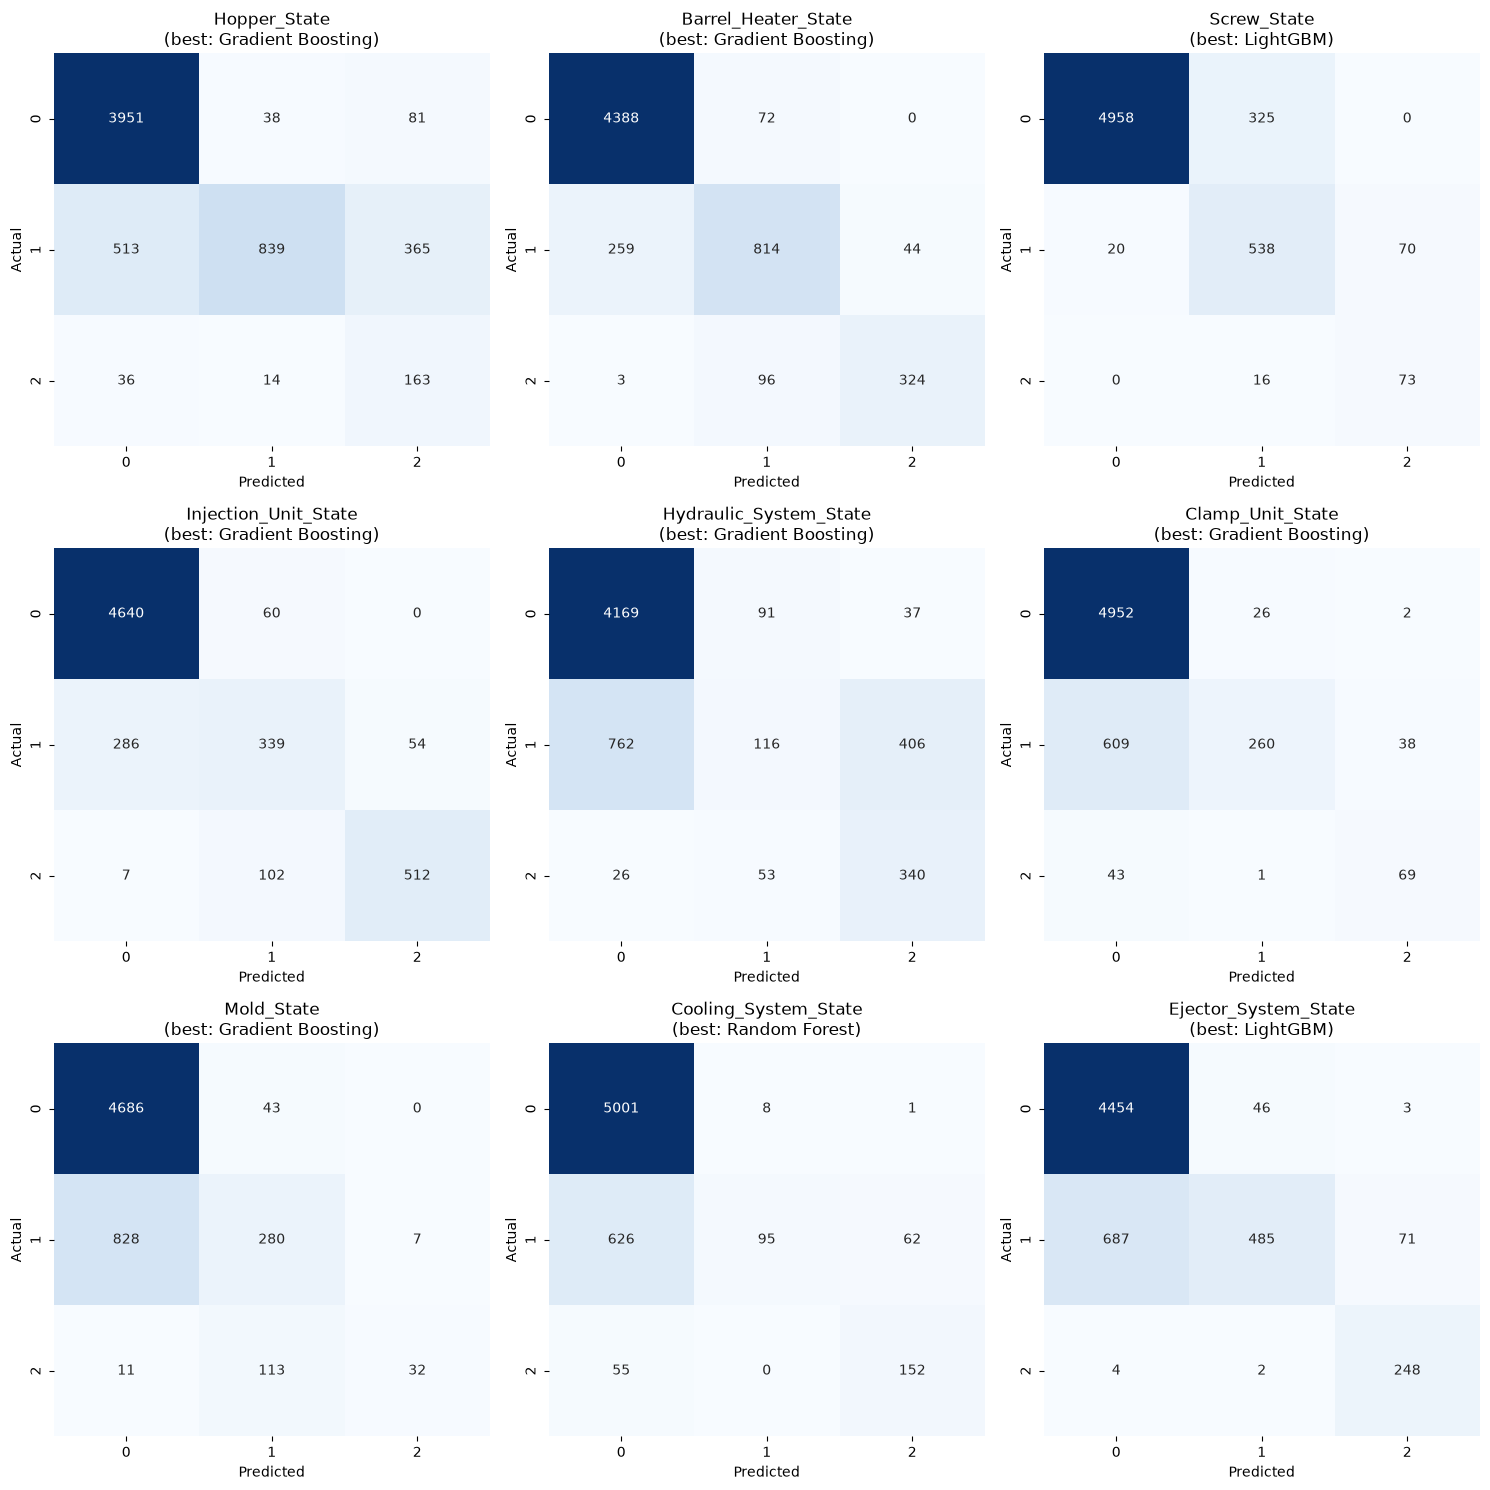

In [34]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for ax, col in zip(axes.flat, target):
    best_model_name = best_model_per_target.loc[col, 'Model']
    model = get_classifiers()[best_model_name]
    model.fit(X_train, train_df[col])
    y_pred = np.asarray(model.predict(X_test)).reshape(-1)
    cm = confusion_matrix(test_df[col], y_pred, labels=[0, 1, 2])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=[0, 1, 2], yticklabels=[0, 1, 2], ax=ax)
    ax.set_title(f'{col}\n(best: {best_model_name})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()